# Stroke Prediction with K-Nearest Neighbors

This is exercise 1 of exchange student Phung Cao Thi Ngoc

## 1. Library Declare

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV # chia train/test
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


## 2. Load the Data 

In [44]:
url = "https://raw.githubusercontent.com/NgocPhungggg/CUT/refs/heads/Introduction_Machine_Learning/Exercises/Exercise_02/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(url)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 3. Data Preprocessing 

### 3.1 Handle any missing values in the dataset using techniques like imputation or removal.

In [45]:
df.isnull().sum() # Check missing values

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [46]:
# Impute missing values for bmi by median values
median_bmi = df["bmi"].median() 
df["bmi"].fillna(median_bmi, inplace=True)
print("---- The median values of BMI column ----")
print(median_bmi)

---- The median values of BMI column ----
28.1


C:\Users\admin\AppData\Local\Temp\ipykernel_13704\380868831.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bmi"].fillna(median_bmi, inplace=True)


### 3.2 Encode categorical variables if necessary using techniques like one-hot encoding. 

In [47]:
# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)  
df_encoded = df_encoded.drop(['id'], axis=1)
df_encoded.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,False,True,False,False,True,False,False,False,True,False


### 3.3 Scale the features to bring them to the same scale, as KNN is sensitive to the scale of features.

In [48]:
X = df_encoded.drop("stroke", axis=1)  # Features
y = df_encoded["stroke"]               # Target label

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)     # Scale features for KNN

## 4. Split the Data

In [49]:
# Split the scaled features and target
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

## 5. Tuning K using Cross-Validation

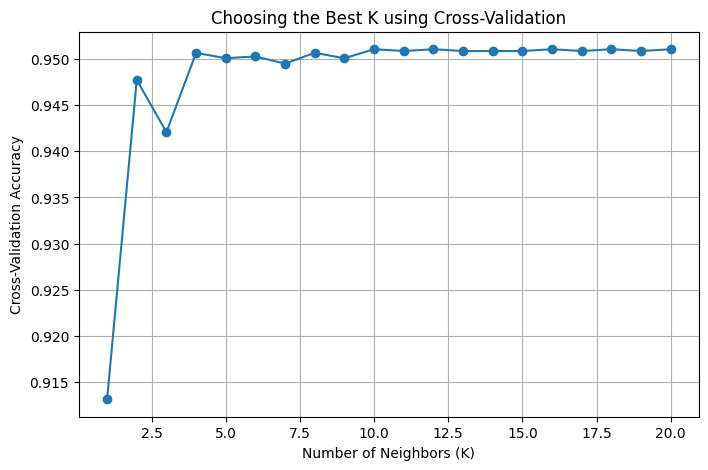

Best K: 10


In [50]:
k_values = range(1, 21)  # Test K from 1 to 20
cv_scores = []           # Store cross-validation scores

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5)  # 5-fold CV
    cv_scores.append(scores.mean())

# Plot accuracy vs. K
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Choosing the Best K using Cross-Validation")
plt.grid(True)
plt.show()

# Best K
best_k = k_values[cv_scores.index(max(cv_scores))]
print("Best K:", best_k)

## 6. Build the KNN Model

In [51]:
# Initialize the KNN model
knn = KNeighborsClassifier(n_neighbors=10)

# Fit the model to the training data
knn.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 7. Evaluate the Model

In [52]:
# Make predictions on the test data
y_pred = knn.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Optional: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.9393346379647749
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Confusion Matrix:
 [[960   0]
 [ 62   0]]


w:\Python\python-3-11-9\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 8. Fine-tune the Model  


In [53]:
# Define the parameter grid for KNN
param_grid = {
    "n_neighbors": range(1, 21),           # Try K from 1 to 20
    "weights": ["uniform", "distance"],    # Uniform or distance-based weights
    "metric": ["euclidean", "manhattan"]   # Distance metrics
}

knn = KNeighborsClassifier()

# Use F1-score because the dataset is imbalanced
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Run grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
print("Best parameters:", grid_search.best_params_)
print("Best F1-score (CV):", grid_search.best_score_)

# Re-train the KNN model using the best parameters
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best F1-score (CV): 0.11247118290851528


,n_neighbors,4
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


### 8.1 Re build the KNN Model with new K

In [54]:
# Initialize the KNN model
knn_new = KNeighborsClassifier(n_neighbors=4)

# Fit the model to the training data
knn_new.fit(X_train, y_train)

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 8.2  Re valuate the new KNN model

In [ ]:
# Make predictions on the test data
y_pred = knn_new.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9383561643835616
Precision: 0.3333333333333333
Recall: 0.016129032258064516
F1-score: 0.03076923076923077

Confusion Matrix:
 [[958   2]
 [ 61   1]]


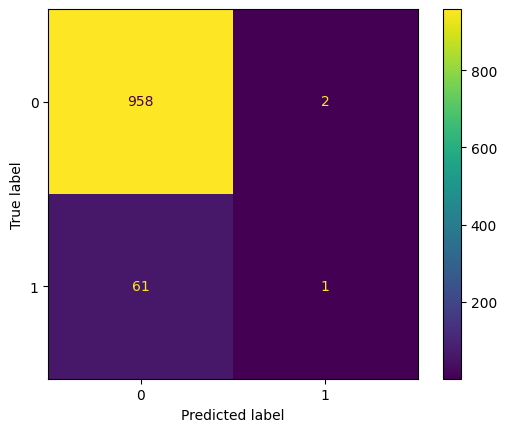

In [56]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## 9. Conclusion

In this exercise, we built and evaluated a K-Nearest Neighbors (KNN) model to predict stroke occurrence based on health-related features. After preprocessing the data, addressing missing values, encoding categorical variables, and scaling the features, we trained the initial KNN model and observed that it achieved a high accuracy (~0.94) but failed to correctly identify any positive stroke cases (precision, recall, and F1-score all equal to 0).

This result revealed a major challenge in the dataset: severe class imbalance, where the majority of instances belong to the non-stroke class. As a distance-based algorithm, KNN naturally favors the majority class, leading to poor performance on the minority class.

Hyperparameter tuning was then performed using GridSearchCV with F1-score as the scoring metric. The best parameters were found to be K = 4, metric = euclidean, and weights = uniform. When evaluating this optimized model, performance improved slightly, achieving:

Accuracy = 0.938

Precision = 0.333

Recall = 0.0161

F1-score = 0.030

Although this is better than the initial model, the improvement remains limited. The optimized KNN model was able to detect some stroke cases (6 true positives), but still missed most of them and produced many false negatives.

Overall, we conclude that KNN is not an appropriate model for this highly imbalanced medical dataset.
Future work should explore techniques such as SMOTE oversampling, class-weighted models, or more robust algorithms such as Logistic Regression (with class balancing), Random Forest, or Gradient Boosting methods, which typically handle imbalanced data more effectively.